In [1]:
!nvidia-smi
!python --version

Sun Oct  4 21:40:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   28C    P0             47W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
!pip uninstall -y datascience albumentations
!apt-get -y install libopenjp2-7-dev libopenjp2-tools sqlite3 libsqlite3-0
!pip install tiatoolbox

Found existing installation: albumentations 2.0.8
Uninstalling albumentations-2.0.8:
  Successfully uninstalled albumentations-2.0.8
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libopenjp2-7-dev is already the newest version (2.5.0-2ubuntu0.5).
libopenjp2-7-dev set to manually installed.
libsqlite3-0 is already the newest version (3.45.1-1ubuntu2.8).
libsqlite3-0 set to manually installed.
Suggested packages:
  sqlite3-doc
The following NEW packages will be installed:
  libopenjp2-tools sqlite3
0 upgraded, 2 newly installed, 0 to remove and 33 not upgraded.
Need to get 224 kB of archives.
After this operation, 835 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 sqlite3 amd64 3.45.1-1ubuntu2.8 [144 kB]
Get:2 http://archive.ubuntu.com/ubuntu noble-updates/universe amd64 libopenjp2-tools amd64 2.5.0-2ubuntu0.5 [79.8 kB]
Fetched 224 kB in 0s (657 kB/s)
Selecting previously unselect

In [3]:
import torch
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch: 2.11.0+cu130
CUDA available: True


In [4]:
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from tiatoolbox.models.engine.nucleus_instance_segmentor import NucleusInstanceSegmentor

segmentor = NucleusInstanceSegmentor(
    model="hovernet_fast-pannuke",
    batch_size=4
)

print("HoVer-Net PanNuke model loaded.")

  segmentor = NucleusInstanceSegmentor(



hovernet_fast-pannuke.pth:   0%|          | 0.00/151M [00:00<?, ?B/s]

HoVer-Net PanNuke model loaded.


In [5]:
import numpy as np
image_list = []
for i in range(10):
    file_path = f"/content/image_{i:03d}.png"


    if file_path is not None:
        image_list.append(file_path)
    else:
        print(f"Warning: Could not load {file_path}")


In [6]:
start_time=time.perf_counter()
results=segmentor.run(images=image_list, patch_mode=True, device="cuda", output_type="dict")
end_time=time.perf_counter()
runtime=end_time-start_time

print(f"Processed {len(results['predictions'])} images")
print(f"Runtime: {runtime:.3f} seconds")

Inferring patches:   0%|          | 0/3 [00:00<?, ?it/s]

Generating 'info_dict' for instances:   0%|          | 0/3 [00:00<?, ?it/s]

Generating 'info_dict' for instances:   0%|          | 0/6 [00:00<?, ?it/s]

Generating 'info_dict' for instances:   0%|          | 0/2 [00:00<?, ?it/s]

Generating 'info_dict' for instances:   0%|          | 0/6 [00:00<?, ?it/s]

...

Generating 'info_dict' for instances:   0%|          | 0/8 [00:00<?, ?it/s]

Generating 'info_dict' for instances:   0%|          | 0/8 [00:00<?, ?it/s]

Generating 'info_dict' for instances:   0%|          | 0/8 [00:00<?, ?it/s]

Generating 'info_dict' for instances:   0%|          | 0/9 [00:00<?, ?it/s]

Processed 10 images
Runtime: 3.437 seconds


In [7]:
print("Image\t\tNuclei\tAvg. Confidence")

for i in range(10):
    count = len(results["type"][i])
    avg_conf = np.mean(results["prob"][i])

    print(
        f"image_{i:03d}.png\t"
        f"{count}\t"
        f"{avg_conf:.3f}"
    )

Image		Nuclei	Avg. Confidence
image_000.png	3	0.991
image_001.png	6	0.707
image_002.png	2	0.980
image_003.png	6	0.975
image_004.png	4	0.960
image_005.png	1	1.000
image_006.png	8	0.979
image_007.png	8	0.920
image_008.png	8	0.945
image_009.png	9	0.960


In [8]:
total_nuclei = sum(len(x) for x in results["type"])

all_probs = np.concatenate(results["prob"])
overall_confidence = np.mean(all_probs)

print(f"\nTotal nuclei detected: {total_nuclei}")
print(f"Average nuclei per patch: {total_nuclei / 10:.1f}")
print(f"Nucleus-weighted mean confidence: {overall_confidence:.3f}")
print(f"Runtime: {runtime:.3f} seconds")


Total nuclei detected: 55
Average nuclei per patch: 5.5
Nucleus-weighted mean confidence: 0.932
Runtime: 3.437 seconds


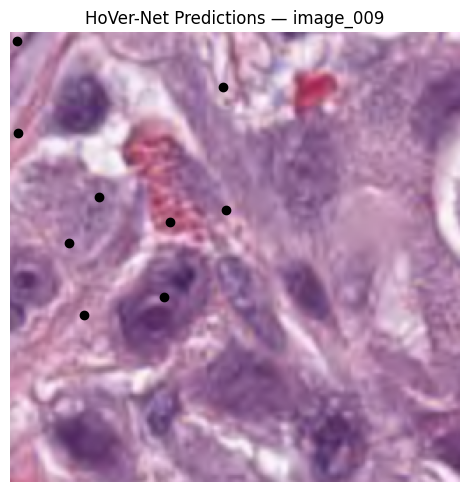

In [9]:
from skimage import color
import matplotlib.pyplot as plt
from PIL import Image

image=Image.open('/content/image_009.png')
plt.imshow(image)
coordinates_array=results['centroid'][9]
plt.scatter(coordinates_array[:, 0],coordinates_array[:, 1], marker='o', color='black')
plt.axis('off')
plt.tight_layout()
plt.title('HoVer-Net Predictions — image_009')
plt.savefig('hovernet_prediction_overlay_009.png', bbox_inches="tight")

In [10]:
import pandas as pd

type_names = {
    1: "Neoplastic",
    2: "Inflammatory",
    3: "Connective",
    4: "Dead",
    5: "Non-neoplastic epithelial",
}

rows = []

for image_idx in range(10):
    centroids = results["centroid"][image_idx]
    types = results["type"][image_idx]
    probs = results["prob"][image_idx]
    boxes = results["box"][image_idx]

    for nucleus_idx in range(len(types)):
        cell_type = int(types[nucleus_idx])

        rows.append({
            "image": f"image_{image_idx:03d}.png",
            "nucleus_id": nucleus_idx,
            "centroid_x": centroids[nucleus_idx][0],
            "centroid_y": centroids[nucleus_idx][1],
            "predicted_type_id": cell_type,
            "predicted_type": type_names.get(cell_type, "Unknown"),
            "confidence": probs[nucleus_idx],
            "bbox_xmin": boxes[nucleus_idx][0],
            "bbox_ymin": boxes[nucleus_idx][1],
            "bbox_xmax": boxes[nucleus_idx][2],
            "bbox_ymax": boxes[nucleus_idx][3],
        })

df = pd.DataFrame(rows)

df.to_csv("hovernet_predictions.csv", index=False)

print(df)
print(f"\nSaved {len(df)} predicted nuclei.")

            image  nucleus_id  centroid_x  centroid_y  predicted_type_id  \
0   image_000.png           0  156.525000    4.668750                  1   
1   image_000.png           1  139.922205   64.092900                  1   
2   image_000.png           2  146.769231  156.305816                  3   
3   image_001.png           0   71.064246   11.862197                  3   
4   image_001.png           1   18.469175   18.683386                  1   
5   image_001.png           2  100.664962   48.199488                  3   
6   image_001.png           3  150.581132   95.777358                  2   
7   image_001.png           4   73.631954  105.641940                  1   
8   image_001.png           5   89.015152  148.219697                  3   
9   image_002.png           0   65.642857   27.805648                  3   
10  image_002.png           1   45.193309   65.130112                  1   
11  image_003.png           0   82.170925   34.563873                  1   
12  image_00